# TCGA Breast Cancer Gene Expression Analysis
By: Sabah Abdulrub

This notebook compares the expression levels of three cancer-related genes (TP53, BRCA1, ERBB2) between breast cancer tumor samples and normal tissue samples using data from The Cancer Genome Atlas (TCGA).

# Section 1: Import Libraries

I use pandas and numpy for data manipulation, matplotlib and seaborn for visualizations, and scipy for statistical testing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Section 2: Load Gene Expression Data

I download the TCGA-BRCA gene expression file directly from UCSC Xena server. The data is in log2(TPM+1) format with 60,000 genes across 1,226 samples.

In [2]:
import urllib.request

url_expr = "https://gdc-hub.s3.us-east-1.amazonaws.com/download/TCGA-BRCA.star_tpm.tsv.gz"
urllib.request.urlretrieve(url_expr, "TCGA-BRCA.star_tpm.tsv.gz")

expr_df = pd.read_csv("TCGA-BRCA.star_tpm.tsv.gz", sep="\t", index_col=0)

print("Gene expression data shape:", expr_df.shape)
print(expr_df.head())

Gene expression data shape: (60660, 1226)
                    TCGA-D8-A146-01A  TCGA-AQ-A0Y5-01A  TCGA-C8-A274-01A  \
Ensembl_ID                                                                 
ENSG00000000003.15          5.662037          3.703721          6.514515   
ENSG00000000005.6           3.376096          0.463099          0.000000   
ENSG00000000419.13          6.860140          7.086452          6.805072   
ENSG00000000457.14          4.400552          4.051007          5.037264   
ENSG00000000460.17          2.845169          2.426989          4.043248   

                    TCGA-BH-A0BD-01A  TCGA-B6-A1KC-01B  TCGA-AC-A62V-01A  \
Ensembl_ID                                                                 
ENSG00000000003.15          4.784917          4.251984          3.536849   
ENSG00000000005.6           2.328061          0.435415          0.736475   
ENSG00000000419.13          6.443071          6.178436          6.823355   
ENSG00000000457.14          4.374970         

# Section 3: Load Clinical Data

I download the clinical file which contains sample metadata including whether each sample is tumor or normal tissue.

In [3]:
url_clin = "https://gdc-hub.s3.us-east-1.amazonaws.com/download/TCGA-BRCA.clinical.tsv.gz"
urllib.request.urlretrieve(url_clin, "TCGA-BRCA.clinical.tsv.gz")

clin_df = pd.read_csv("TCGA-BRCA.clinical.tsv.gz", sep="\t", index_col=0)

print("Clinical data shape:", clin_df.shape)
print(clin_df.head())

Clinical data shape: (1255, 84)
                                                    id  \
sample                                                   
TCGA-BH-A0W3-01A  3c612e12-6de8-44fa-a095-805c45474821   
TCGA-AR-A24V-01A  3cb06c7a-f2a8-448b-91a8-dd201bbf2ddd   
TCGA-E9-A1NE-01A  3d676bba-154b-4d22-ab59-d4d4da051b94   
TCGA-E9-A1NE-11A  3d676bba-154b-4d22-ab59-d4d4da051b94   
TCGA-AC-A8OQ-01A  dfaabd03-2d40-4422-b210-caf112ff4229   

                                  disease_type  \
sample                                           
TCGA-BH-A0W3-01A  Ductal and Lobular Neoplasms   
TCGA-AR-A24V-01A  Ductal and Lobular Neoplasms   
TCGA-E9-A1NE-01A  Ductal and Lobular Neoplasms   
TCGA-E9-A1NE-11A  Ductal and Lobular Neoplasms   
TCGA-AC-A8OQ-01A  Ductal and Lobular Neoplasms   

                                               case_id  submitter_id  \
sample                                                                 
TCGA-BH-A0W3-01A  3c612e12-6de8-44fa-a095-805c45474821  TCGA-BH-A0

# Section 4: Filter for Genes of Interest

I filter the expression data to keep only the three genes I am studying: TP53, BRCA1, and ERBB2, identified by their Ensembl IDs.

In [4]:
genes_of_interest = {
    "TP53": "ENSG00000141510",
    "BRCA1": "ENSG00000012048",
    "ERBB2": "ENSG00000141736"
}

gene_expr = expr_df[expr_df.index.str.startswith(tuple(genes_of_interest.values()))]

gene_expr.index = ["BRCA1", "ERBB2", "TP53"]

print(gene_expr.shape)
print(gene_expr)

(3, 1226)
       TCGA-D8-A146-01A  TCGA-AQ-A0Y5-01A  TCGA-C8-A274-01A  TCGA-BH-A0BD-01A  \
BRCA1          2.302465          2.356848          3.380064          3.907535   
ERBB2          5.491821          5.149097          5.917114          6.252266   
TP53           6.520847         11.264096          7.177807          6.468011   

       TCGA-B6-A1KC-01B  TCGA-AC-A62V-01A  TCGA-AO-A0J5-01A  TCGA-BH-A0B1-01A  \
BRCA1          3.630336          2.623703          2.159629          3.900393   
ERBB2          5.293334          4.911610          5.892362          5.237112   
TP53           5.888553          6.498363          7.022392          6.697307   

       TCGA-A2-A0YM-01A  TCGA-AO-A03N-01B  ...  TCGA-E2-A1IG-01A  \
BRCA1          3.130536          1.872159  ...          3.812098   
ERBB2          6.125455          5.323662  ...          5.522950   
TP53           6.476412          4.460952  ...          7.342991   

       TCGA-E9-A1NA-01A  TCGA-D8-A1JP-01A  TCGA-AR-A252-01A  TCGA-D

# Section 5: Label Samples as Tumor or Normal

I use the clinical file to assign each sample a tissue type label of either Tumor or Normal, then merge it with the expression data. Samples with missing labels are dropped.

In [5]:
# Extract the tissue type column from clinical data
tissue_labels = clin_df["tissue_type.samples"]

# Transpose gene expression so samples are rows
gene_expr_T = gene_expr.T

# Add the tissue type label to each sample
gene_expr_T["tissue_type"] = tissue_labels

# Drop any samples where tissue type is missing
gene_expr_T = gene_expr_T.dropna(subset=["tissue_type"])

# Check how many tumor vs normal samples I have
print(gene_expr_T["tissue_type"].value_counts())
print(gene_expr_T.head())

tissue_type
Tumor     1113
Normal     113
Name: count, dtype: int64
                     BRCA1     ERBB2       TP53 tissue_type
TCGA-D8-A146-01A  2.302465  5.491821   6.520847       Tumor
TCGA-AQ-A0Y5-01A  2.356848  5.149097  11.264096       Tumor
TCGA-C8-A274-01A  3.380064  5.917114   7.177807       Tumor
TCGA-BH-A0BD-01A  3.907535  6.252266   6.468011       Tumor
TCGA-B6-A1KC-01B  3.630336  5.293334   5.888553       Tumor


# Section 6: Statistical Testing

I run an independent samples t-test for each gene to check whether the difference in expression between tumor and normal samples is statistically significant (p < 0.05).

In [6]:
genes = ["BRCA1", "ERBB2", "TP53"]

for gene in genes:
    tumor_vals = gene_expr_T[gene_expr_T["tissue_type"] == "Tumor"][gene]
    normal_vals = gene_expr_T[gene_expr_T["tissue_type"] == "Normal"][gene]

    t_stat, p_val = stats.ttest_ind(tumor_vals, normal_vals)

    print(f"{gene}:")
    print(f"  Tumor mean:  {tumor_vals.mean():.4f}")
    print(f"  Normal mean: {normal_vals.mean():.4f}")
    print(f"  P-value:     {p_val:.4e}")
    print()

BRCA1:
  Tumor mean:  2.9903
  Normal mean: 2.2507
  P-value:     2.4683e-16

ERBB2:
  Tumor mean:  5.5233
  Normal mean: 5.4219
  P-value:     2.3613e-01

TP53:
  Tumor mean:  7.0523
  Normal mean: 5.9514
  P-value:     3.6522e-13



# Section 7: Figure 1 - Boxplots

Boxplots showing the distribution of expression levels for each gene in tumor vs. normal samples side by side.

/tmp/ipykernel_7038/3382878188.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_7038/3382878188.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_7038/3382878188.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


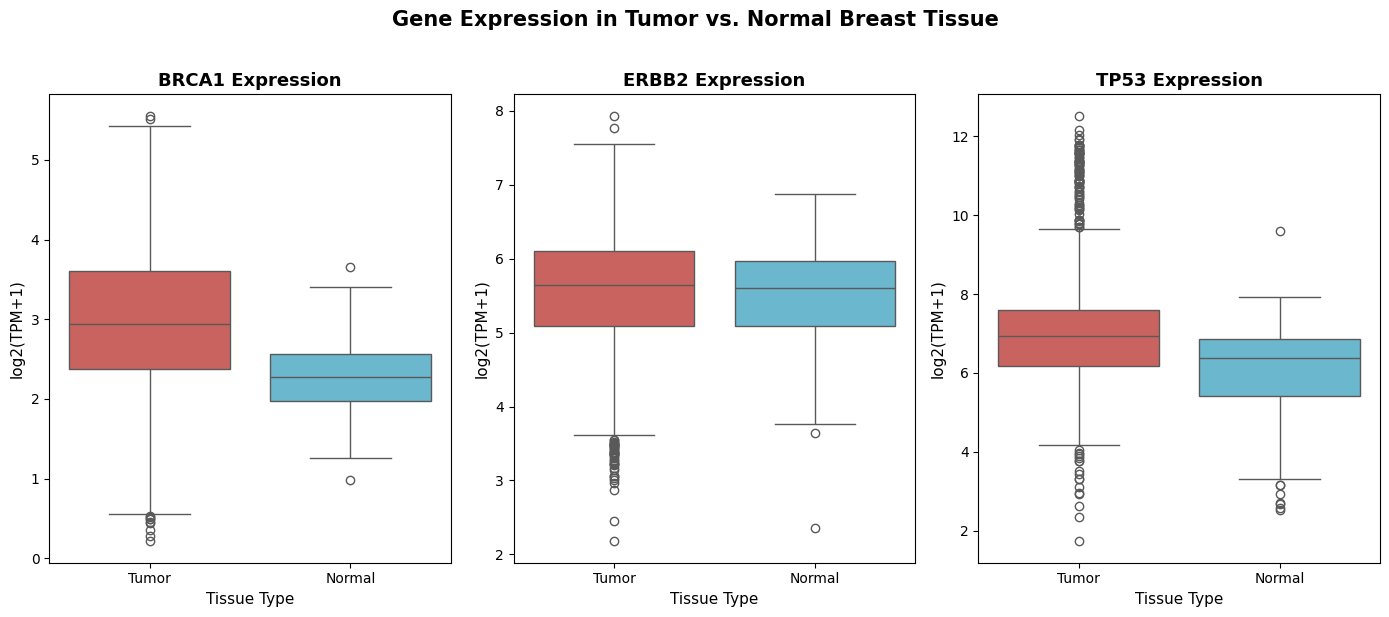

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 6))

genes = ["BRCA1", "ERBB2", "TP53"]
colors = {"Tumor": "#d9534f", "Normal": "#5bc0de"}

for i, gene in enumerate(genes):
    sns.boxplot(
        data=gene_expr_T,
        x="tissue_type",
        y=gene,
        palette=colors,
        ax=axes[i]
    )
    axes[i].set_title(f"{gene} Expression", fontsize=13, fontweight="bold")
    axes[i].set_xlabel("Tissue Type", fontsize=11)
    axes[i].set_ylabel("log2(TPM+1)", fontsize=11)

plt.suptitle("Gene Expression in Tumor vs. Normal Breast Tissue",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figure1_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

# Section 8:  Figure 2 - Heatmap

Heatmap displaying expression levels across all three genes for a random subset of 50 tumor and 50 normal samples.

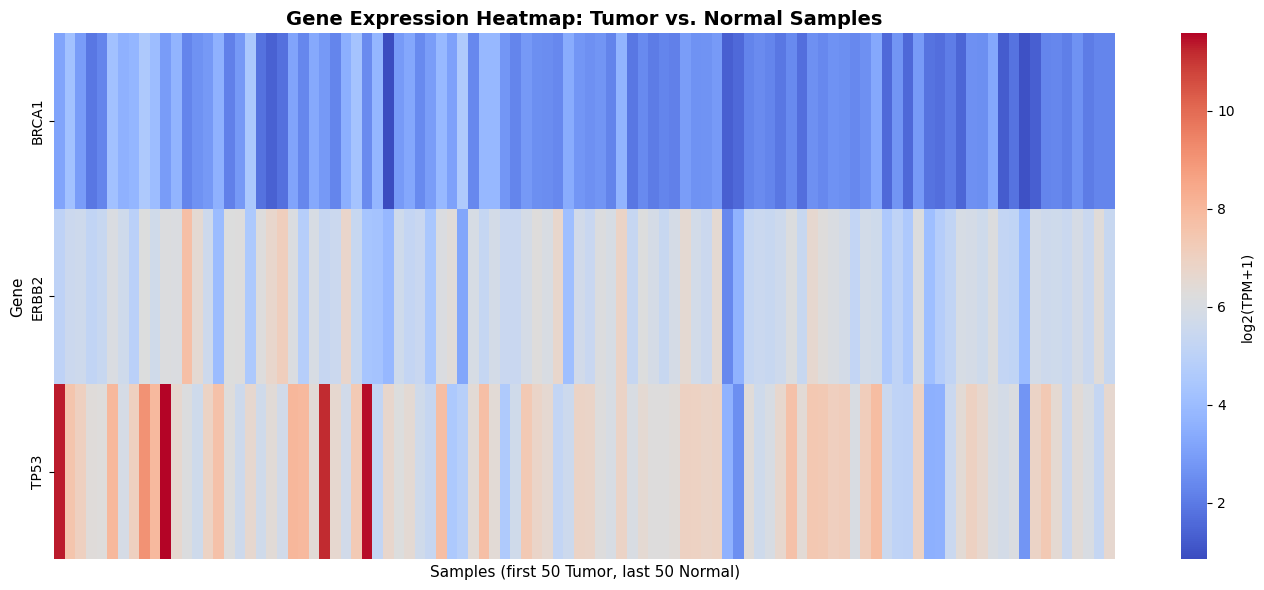

In [8]:
# Take a random sample of 50 tumor and 50 normal for visibility
tumor_sample = gene_expr_T[gene_expr_T["tissue_type"] == "Tumor"].sample(50, random_state=42)
normal_sample = gene_expr_T[gene_expr_T["tissue_type"] == "Normal"].sample(50, random_state=42)

heatmap_data = pd.concat([tumor_sample, normal_sample])

# Create color bar for tissue type
tissue_colors = heatmap_data["tissue_type"].map({"Tumor": "#d9534f", "Normal": "#5bc0de"})

# Plot heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(
    heatmap_data[["BRCA1", "ERBB2", "TP53"]].T,
    cmap="coolwarm",
    xticklabels=False,
    yticklabels=True,
    linewidths=0,
    cbar_kws={"label": "log2(TPM+1)"}
)

plt.title("Gene Expression Heatmap: Tumor vs. Normal Samples",
          fontsize=14, fontweight="bold")
plt.xlabel("Samples (first 50 Tumor, last 50 Normal)", fontsize=11)
plt.ylabel("Gene", fontsize=11)
plt.tight_layout()
plt.savefig("figure2_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Section 9: Figure 3 - Bar Chart

Bar chart summarizing the average expression of each gene in tumor vs. normal tissue with error bars showing variablility.

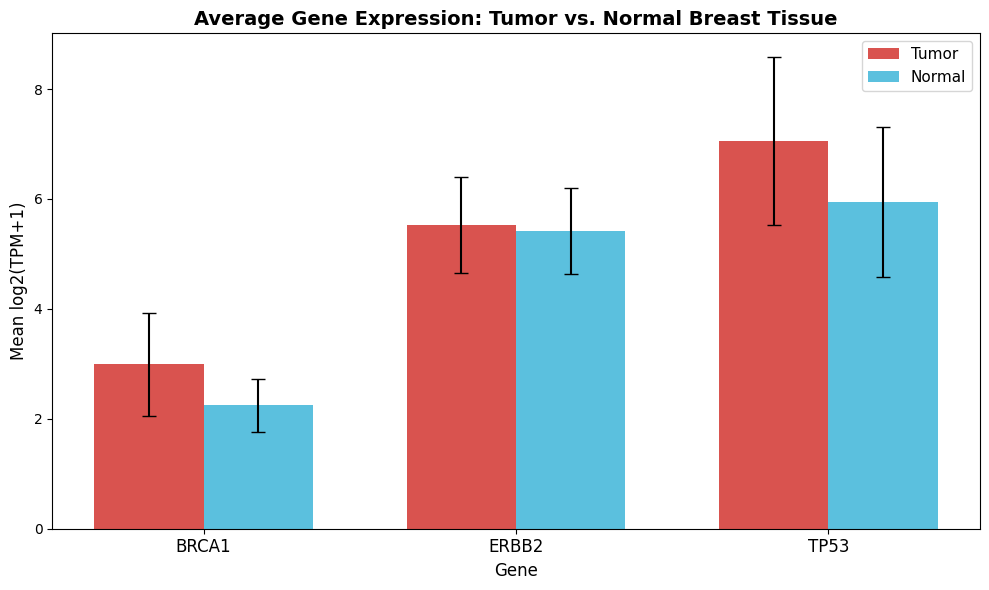

In [9]:
genes = ["BRCA1", "ERBB2", "TP53"]

tumor_means = [gene_expr_T[gene_expr_T["tissue_type"] == "Tumor"][gene].mean() for gene in genes]
normal_means = [gene_expr_T[gene_expr_T["tissue_type"] == "Normal"][gene].mean() for gene in genes]

tumor_stds = [gene_expr_T[gene_expr_T["tissue_type"] == "Tumor"][gene].std() for gene in genes]
normal_stds = [gene_expr_T[gene_expr_T["tissue_type"] == "Normal"][gene].std() for gene in genes]

x = np.arange(len(genes))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, tumor_means, width, yerr=tumor_stds,
               label="Tumor", color="#d9534f", capsize=5)
bars2 = ax.bar(x + width/2, normal_means, width, yerr=normal_stds,
               label="Normal", color="#5bc0de", capsize=5)

ax.set_xlabel("Gene", fontsize=12)
ax.set_ylabel("Mean log2(TPM+1)", fontsize=12)
ax.set_title("Average Gene Expression: Tumor vs. Normal Breast Tissue",
             fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(genes, fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig("figure3_barchart.png", dpi=150, bbox_inches="tight")
plt.show()